## Objectives

In this chapter, you will able learn the following,

- Introduction to SIFT
- Motivation and background
- SIFT algorithm
- Applications

## Prerequisites

For the better understanding of this chapter, following are some prerequisities but not mandatory.

- Basic ideas of computer vision
- Basic calculus

## Introduction

Let's recall the example you have already seen in the first chapter about creating the panorama from two images. Since both images are on the same scale and same orientation, we could easily create a panorama.

However, in a real-world application, the problem may go much harder. What if those images are of different scaling and orientation or rotations? Identifying the matching keypoints will be much harder, right? The formulation of these problems can be shown in the images below.

<center>
<figure>
<!-- <img src="https://docs.google.com/uc?export=download&id=1KlNDPsjYUR0rfYhR3P22fo6_S2AKomxU"> -->
<img src="https://i.postimg.cc/MHdrv3c0/image.png">
<figcaption align="center">Fig. 1: Images with different scaling</figcaption>
</figure>
</center>



In the above images, the features of right-side images are different from those of the left side due to scaling, although they are the same features. Similarly, the figure below represents the features matching problem due to rotation.

<center>
<figure>
<!-- <img src="https://docs.google.com/uc?export=download&id=1DkdDK1G9PG1vkzF4ajgj416QfReQSf3t"> -->
<img src="https://i.postimg.cc/ydWDMkmV/image.png">
<figcaption align="center">Fig. 2: Images with different rotation</figcaption>
</figure>
</center>

Hence, we need a robust tool that is invariant to these scaling and rotations problems while matching the detected features of the images. Here comes a handy algorithm called SIFT (Scale Invariant Feature Transform), which is invariant to both the scaling and rotations.

By definition, Scale Invariant Feature Transform (SIFT) is a feature detection algorithm that falls under the computer vision to detect and describe local features in an image. We will explain this algorithm in detail in the following sections.


## Background and Motivation

SIFT algorithm was first published in a [paper](https://www.cs.ubc.ca/~lowe/papers/ijcv04.pdf) by David Lowe in 1999 and patented by the University of British Columbia in Canada. This algorithm solves the drawbacks of the Harris corner detector. We are already familiar with the Harris corner detector algorithm. One problem with this algorithm is it is not scale-invariant. To better understanding, consider the following image.

<center>
<figure>
<!-- <img src="https://docs.google.com/uc?export=download&id=16f0CCGauw8QT1liPUevTxrAcAG4ULLjR" width=700> -->
<img src="https://i.postimg.cc/PxVz8Cbc/image.png">
<figcaption align="center">Fig. 3: Drawback of Harris corner detector</figcaption>
</figure>
</center>

According to the Harris corner algorithm, the image before scaling treated as a corner. However, after scaling, the same image treated as an edge. Hence, we need a robust algorithm to address this problem of scaling, and the SIFT algorithm does the same.

Although Harris corner is rotation invariant, SIFT is invariant to both scaling and rotation. Hence, SIFT turns out to more robust feature descriptor algorithm by eliminating the Harris corner detector's weakness.

## SIFT Algorithm

Let's talk about the core of this reading material, i.e., SIFT algorithm. The following two flowcharts gives the overview of the SIFT algorithm. The left algorithm is a little more in depth than the right side one. We will discuss each step in detail in the following section.

<center>
<figure>
<!-- <img src="https://docs.google.com/uc?export=download&id=1s8qtTq1rXK84xjDYbvAhHLqz_J-uUhVt" height=400> -->
<img src="https://i.postimg.cc/pT5Yz20L/image.png"/>
<figcaption align="center">Fig. 4: Flowchart of SIFT procedure</figcaption>
</figure>
</center>



### **1. Scale-Space Extrema Detection**


The SIFT algorithm is designed to detect and describe local features in images, even when the images have been scaled differently. It does this by maximizing the Difference of Gaussians (DoG) in both scale and space.

When comparing two identical images that have been scaled differently, the SIFT algorithm will use the DoG to find the same keypoints in each image. The DoG is calculated by taking the difference between two Gaussian-blurred versions of an image, each with a different standard deviation.

The SIFT algorithm uses a process called "scale-space extrema detection" to detect keypoints in the image. This process begins by building a scale-space representation of the image using the DoG function. The DoG function is calculated by convolving the image with increasingly larger Gaussian kernels and taking the difference between each resulting image. Extrema (local maxima and minima) are then detected in the scale-normalized DoG function. These extrema are potential keypoints in the image.

The SIFT algorithm repeats this process for different scales, also called octaves, in the image. Each octave is blurred with Gaussians with standard deviations of different scaling factors, and the differences between adjacent Gaussian-blurred images are calculated as DoG. This allows the SIFT algorithm to detect keypoints in the image at different scales, making it more robust to changes in scale.




<center>
<figure>
<!-- <img src="https://docs.google.com/uc?export=download&id=1XZxP3kFiUFb6Bfl_-JC6ho0xwbYuKP1I" height=400 width=700> -->

<img src="https://i.postimg.cc/J76MGMfk/image.png" height=400 width=700>

<figcaption align="center">Fig. 5: Showing Difference of Gaussian (DoG)</figcaption>
</figure>
</center>





  


### **2. Keypoint Localization**
When the DoG is found, the SIFT detector searches the DoG over scale and space for local extremas, which can be potential keypoints. For example, one pixel (marked with X) in an image is compared with its 9 neighbors (marked with circles) at the current and adjacent scales. If the pixel is greater or smaller than all its neighbors, then it is a local extrema and is a potential keypoint in that scale.

<center>
<figure>
<img src="https://i.postimg.cc/wBy0ccMz/image.png" >
<figcaption align="center">Fig. 6: Comparing single pixel to neighboring pixels of different scales</figcaption>
</figure>
</center>

SIFT use DoG to identify key points independently in each image, regardless of the scales of the images by building scale-space representation of the image and detecting extrema (local maxima and minima) in the scale-normalized DoG function. It repeats this process for different octaves in the image to detect keypoints at different scales.
  


### **3. Orientation Assignment**

<center>
<figure>
<img src="https://i.postimg.cc/jdBWnzpP/image.png" >
<figcaption align="center">Fig. 7: Orientation of pixel and respective histogram</figcaption>
</figure>
</center>

Orientation assignment is the third step of the SIFT algorithm. It assigns an orientation to each keypoint that was detected in the previous steps, in order to achieve invariance to image rotation. In this step, a neighborhood is taken around the keypoint location, depending on the scale, and the gradient magnitude and direction is calculated within that region. An orientation histogram with 36 bins covering 360 degrees is created, with the histogram values weighted by both the gradient magnitude and a gaussian-weighted circular window with a standard deviation equal to 1.5 times the scale of the keypoint. The highest peak in the histogram is taken as the dominant orientation for the keypoint, and any peaks above 80% of the highest peak are also considered in order to calculate the orientation. This step creates keypoints with the same location and scale, but different orientations, which contributes to the stability of matching in later steps.



### **4. Keypoint Descriptor**

<center>
<figure>
<img src="https://i.postimg.cc/6Qn1xfX0/image.png" >
<figcaption align="center">Fig. 8: Each keypoint descriptor vector</figcaption>
</figure>
</center>

In the fourth step of SIFT algorithm, a descriptor is created for each keypoint. A 16x16 neighborhood around the keypoint is divided into 16 sub-blocks, each with its own 8-bin orientation histogram resulting in a total of 128-bin values vector. This descriptor is a compact representation of the local neighborhood around the keypoint and is used to identify and match keypoints between images. Additional measures are taken to increase the robustness of the descriptor against changes in illumination and rotation.


### **5. Keypoint Matching**


The final step of the SIFT algorithm is keypoint matching, which is used to match keypoints between two images. In this step, keypoints are matched by identifying their nearest neighbors and comparing their descriptors. However, in some cases, the second closest match may be very similar to the first, due to noise or other reasons. To address this, the ratio of the closest distance to the second closest distance is taken, and if it is greater than 0.8, the match is rejected. This method eliminates around 90% of false matches while discarding only 5% of correct matches, as reported in the original SIFT paper.









Well, we described all the steps of SIFT algorithm. However, it is an iterative approach. The process will repeated until keypoint descritors are of all scale and for all octaves. Otherwise, the process will redirected to DoG generation again.

## Applications

Since SIFT finds the distinctive keypoints that are invariant to scale, rotation, location, and robust to changes in illuminations and various affine transformations, applications of the SIFT algorithm in the computer vision field are limitless. Some of them where SIFT algorithm used, are,

- Object Recognition
- Image stitching
- Robotic Mapping
- Video Tracking
- Gesture Recognition
- 3D Modeling
- Individual Identification of moving object

For all applications mentioned above, first, SIFT features are obtained from an input image by applying the SIFT algorithm. These features can be used for various matching purposes. For eg., in image stitching applications, the features of two images can compared and merged accordingly. In the same way, these features are helpful for object recognition, 3D modeling, video tracking, etc.

## SIFT Implementation

Let's implement the SIFT algorithm to see how it detects the key points of an image from the `opencv` library.

SIFT algorithm was first published in a [paper](https://www.cs.ubc.ca/~lowe/papers/ijcv04.pdf) by David Lowe in 1999 and patented by the University of British Columbia (UBC) in Canada.

Since the UBC patents SIFT, `opencv` library doesn't provide this function by `cv2.SIFT()`. Hence, we should have to install `opencv-contrib` library explicitly as following,

In [ ]:
# Install opencv-contrib library
!pip install opencv-contrib-python==3.4.2.17

     |████████████████████████████████| 30.6MB 134kB/s 
  Found existing installation: opencv-contrib-python 4.1.2.30
    Uninstalling opencv-contrib-python-4.1.2.30:
      Successfully uninstalled opencv-contrib-python-4.1.2.30


In [1]:
### DOWNLOAD IMAGES FOR IMPLEMENTATION
!wget -O dog.jpg https://imgur.com/aeZVeM9.jpg
!wget -O book.jpg https://imgur.com/kztoYod.jpg
!wget -O books.jpg https://imgur.com/COaQRaM.jpg
# !wget -O box_in_scene.png https://imgur.com/KdBpgCZ.png
# !wget -O box.png https://imgur.com/mmsJrSg.png

--2025-08-20 15:26:38--  https://imgur.com/aeZVeM9.jpg
Resolving imgur.com (imgur.com)... 199.232.192.193, 199.232.196.193
Connecting to imgur.com (imgur.com)|199.232.192.193|:443... 

connected.
HTTP request sent, awaiting response... 429 Unknown Error
2025-08-20 15:26:39 ERROR 429: Unknown Error.

--2025-08-20 15:26:39--  https://imgur.com/kztoYod.jpg
Resolving imgur.com (imgur.com)... 199.232.196.193, 199.232.192.193
Connecting to imgur.com (imgur.com)|199.232.196.193|:443... connected.
HTTP request sent, awaiting response... 429 Unknown Error
2025-08-20 15:26:41 ERROR 429: Unknown Error.

--2025-08-20 15:26:41--  https://imgur.com/COaQRaM.jpg
Resolving imgur.com (imgur.com)... 199.232.196.193, 199.232.192.193
Connecting to imgur.com (imgur.com)|199.232.196.193|:443... connected.
HTTP request sent, awaiting response... 429 Unknown Error
2025-08-20 15:26:42 ERROR 429: Unknown Error.



In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [20, 10]

def get_keypoints(input_image):
    # Initiate SIFT detector
    sift = cv2.xfeatures2d.SIFT_create()
    keypoints, descriptor = sift.detectAndCompute(input_image, None)
    return keypoints, descriptor


In [ ]:
input_image = cv2.imread('dog.jpg', 0)
keypoints, _ = get_keypoints(input_image)
output_image = cv2.drawKeypoints(input_image,
                        keypoints,
                        input_image)

plt.axis('off')
plt.imshow(output_image)

Cool, right? `opencv` library also provides another function `cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS` which draws the circle around the key points. For this, flag should be passed to this function and circles with the size of keypoint are drawn. Along with that, it will gives the orientation of that keypoint as well.

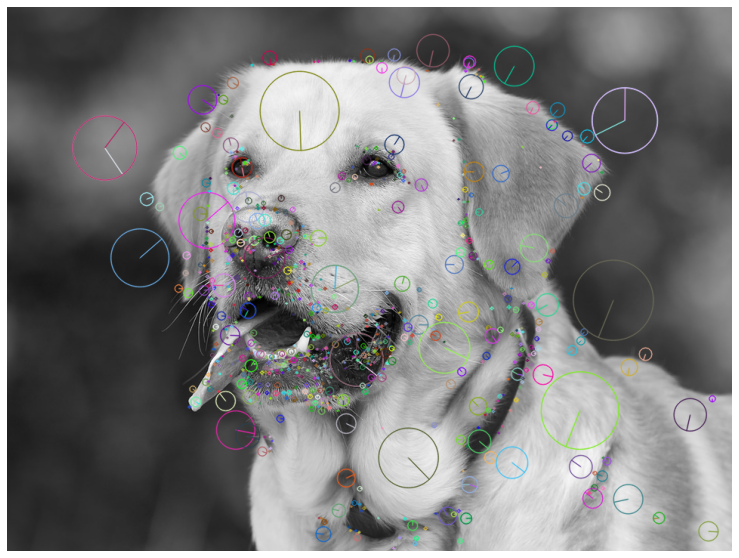

In [ ]:
keypoints_flag = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
out_image = cv2.drawKeypoints(input_image,
                   keypoints,
                   input_image,
                   flags=keypoints_flag)
plt.axis('off')
plt.imshow(out_image)

## Brute force matching Implementation

After extracing feature descriptors, the final step is to match the correspondeces between the images features using imahe matching algorithms. We have already discussed Brute Force Matching algorithm in previous chapters. So, let's implement it now.

We will use SIFT Descriptor as feature descriptors in this implementation.

In [ ]:
def get_matches(des1, des2):
    # Brute Force Matcher with default params
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)

    # Apply ratio test
    good_matches = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append([m])
    return good_matches

def match_images(query_img_path, train_img_path):

    query_img = cv2.imread(query_img_path, 0) # queryImage
    train_img = cv2.imread(train_img_path, 0) # trainImage

    # find the keypoints and descriptors with SIFT
    kp1, des1 = get_keypoints(query_img)
    kp2, des2 = get_keypoints(train_img)

    good_matches = get_matches(des1, des2)

    # cv2.drawMatchesKnn expects list of lists as matches.
    target_img = cv2.drawMatchesKnn(query_img, kp1, train_img, kp2, good_matches, None, flags=2)
    return target_img



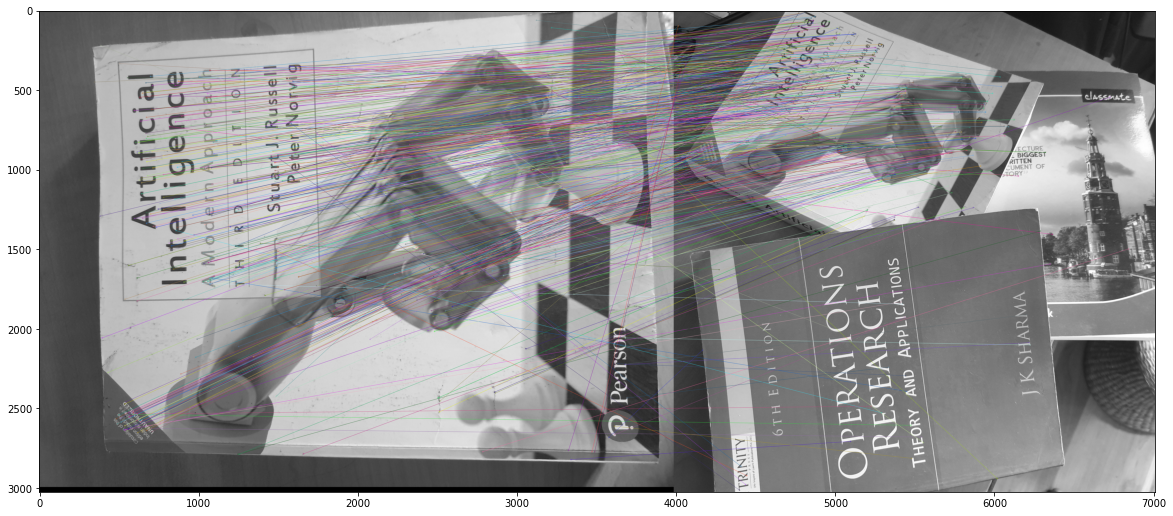

In [ ]:
matched_image = match_images('book.jpg', 'books.jpg')
plt.imshow(matched_image)